# Модуль 18. Нейронные рекомендатели и ранжирование

Ноутбук к [модулю 18](https://drobyshevdev.github.io/lemma/modules/18-neural-recommenders-and-ranking/).

Метрики ранжирования руками, two-tower на признаках (и холодный старт), и главное — почему офлайн-метрика на логах оптимистична и слепа. Только `numpy` и `matplotlib`.

**Читайте дважды:** сначала целиком, потом ломая.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

## 1. Метрики ранжирования

Рекомендатель упорядочивает, а не отвечает «да/нет». Метрики смотрят на порядок: precision@k — доля релевантного в топ-k; NDCG — то же с логарифмическим весом позиции; MRR — обратный ранг первого релевантного.

идеальный порядок: NDCG = 1.00, precision@3 = 1.00, MRR = 1.00


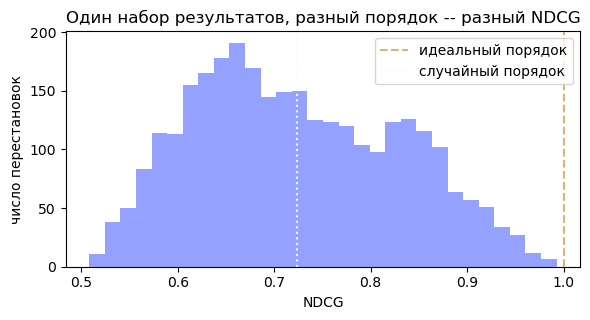

случайный порядок в среднем NDCG = 0.72: тот же набор, но релевантное не наверху


In [2]:
rel = np.array([3, 0, 2, 3, 1, 0, 2, 0, 1, 0])   # градуированная релевантность 10 результатов

def dcg(order): return sum(rel[i] / np.log2(pos + 2) for pos, i in enumerate(order))
def ndcg(order): ideal = sorted(range(len(rel)), key=lambda i: -rel[i]); return dcg(order) / dcg(ideal)
def precision_at_k(order, k): return np.mean([rel[i] > 0 for i in order[:k]])
def mrr(order):
    for pos, i in enumerate(order):
        if rel[i] > 0: return 1 / (pos + 1)
    return 0.0

ideal = sorted(range(len(rel)), key=lambda i: -rel[i])
print("идеальный порядок: NDCG = %.2f, precision@3 = %.2f, MRR = %.2f"
      % (ndcg(ideal), precision_at_k(ideal, 3), mrr(ideal)))

ndcgs = []
for _ in range(3000):
    o = rng.permutation(len(rel))
    ndcgs.append(ndcg(o))
fig, ax = plt.subplots(figsize=(6, 3.3))
ax.hist(ndcgs, bins=30, color="#7b8aff", alpha=0.8)
ax.axvline(1.0, color="#d8b678", ls="--", label="идеальный порядок")
ax.axvline(np.mean(ndcgs), color="#f8f9fb", ls=":", label="случайный порядок")
ax.set_xlabel("NDCG"); ax.set_ylabel("число перестановок")
ax.set_title("Один набор результатов, разный порядок -- разный NDCG")
ax.legend(); plt.tight_layout(); plt.show()
print("случайный порядок в среднем NDCG = %.2f: тот же набор, но релевантное не наверху" % np.mean(ndcgs))

Набор результатов один и тот же, а NDCG гуляет от 1.0 (идеально) до среднего у случайного порядка. Балл товара не изменился — изменился порядок, и именно его награждает метрика.

**Сломать.** Сделайте все релевантности равными (`rel[:] = 1`) — NDCG станет 1.0 при любом порядке: когда всё одинаково важно, порядок не значит ничего.

## 2. Two-tower и холодный старт

Башня пользователя сжимает **признаки** в вектор, башня товара — тоже. Оценка — их скалярное произведение. Раз вектор строится из признаков, новому пользователю без истории всё равно есть что рекомендовать — чего матричное разложение из модуля 17 не умеет.

In [3]:
N_U, N_I, DF, K = 150, 40, 6, 4
# истинный вкус пользователя и свойства товара -- линейная функция их признаков
Au = rng.normal(0, 1, (DF, K)); Av = rng.normal(0, 1, (DF, K))
user_feat = rng.normal(0, 1, (N_U, DF))
item_feat = rng.normal(0, 1, (N_I, DF))
true_u = user_feat @ Au; true_v = item_feat @ Av
R = (true_u @ true_v.T + rng.normal(0, 0.5, (N_U, N_I))) > 1.0   # взаимодействия

def sigmoid(z): return 1 / (1 + np.exp(-z))

# обучаем две башни (линейные) предсказывать взаимодействия
Wu = rng.normal(0, 0.1, (DF, K)); Wv = rng.normal(0, 0.1, (DF, K))
for _ in range(600):
    U = user_feat @ Wu; V = item_feat @ Wv
    P = sigmoid(U @ V.T); E = P - R
    Wu -= 0.02 * (user_feat.T @ (E @ V)) / N_U
    Wv -= 0.02 * (item_feat.T @ (E.T @ U)) / N_I

# новый пользователь: только признаки, история пустая
new_feat = rng.normal(0, 1, DF)
new_u = new_feat @ Wu
rec = np.argsort(-(new_u @ (item_feat @ Wv).T))[:5]
true_rank = np.argsort(-(new_feat @ Au @ (item_feat @ Av).T))[:5]
print("two-tower рекомендует новому пользователю товары:", rec.tolist())
print("его истинный топ по вкусу:                        ", true_rank.tolist())
print("совпадений в топ-5:", len(set(rec) & set(true_rank)),
      "-- вектор построен из признаков, без единого лайка")

two-tower рекомендует новому пользователю товары: [14, 26, 25, 23, 1]
его истинный топ по вкусу:                         [14, 26, 25, 23, 33]
совпадений в топ-5: 4 -- вектор построен из признаков, без единого лайка


Новому пользователю башня собрала вектор из признаков и попала в его истинный вкус — история не понадобилась. Матричное разложение из модуля 17 здесь молчит: у нового пользователя нет id-эмбеддинга, строить не из чего. Признаки в башнях — это и есть лечение холодного старта.

**Сломать.** Обнулите признаки нового пользователя (`new_feat = np.zeros(DF)`) — рекомендация выродится в один и тот же список: без признаков башне тоже не за что зацепиться.

## 3. Офлайн против онлайн

Логи собрал **старый рекомендатель**: клик возможен только по показанному. Товар, который был бы хорош, но его не показывали, в логах выглядит непопулярным. Модель, обученная на логах, наследует эту слепоту, а офлайн-метрика её не ловит — она считается на тех же логах.

In [4]:
# истинная релевантность и экспозиция старого рекомендателя (показывал в основном популярное)
true_rel = (rng.random((N_U, N_I)) < 0.25)                 # кто что действительно оценил бы
item_pop = rng.random(N_I) ** 2
exposed = rng.random((N_U, N_I)) < (0.15 + 0.7 * item_pop)  # что старый показал
log_clicks = true_rel & exposed                            # клик = релевантно И показано

# наивная модель: балл товара = сколько кликов в логе (популярность в логе)
naive_score = log_clicks.sum(0).astype(float)

def recall_topk(score, mask, k=5):
    hits = tot = 0
    for u in range(N_U):
        rel_items = np.where(true_rel[u] & mask[u])[0]
        if len(rel_items) == 0: continue
        top = np.argsort(-score)[:k]
        hits += len(set(top) & set(rel_items)); tot += len(rel_items)
    return hits / max(tot, 1)

seen = exposed
unseen = ~exposed
print("наивная модель, recall@5 по релевантным, которые старый ПОКАЗЫВАЛ:   %.2f" % recall_topk(naive_score, seen))
print("наивная модель, recall@5 по релевантным, которые старый НЕ показывал: %.2f" % recall_topk(naive_score, unseen))
print()
print("офлайн-метрика хвалит модель на показанном и слепа к непоказанному:")
print("разрыв -- это цена смещения логов, и офлайн её не видит")

наивная модель, recall@5 по релевантным, которые старый ПОКАЗЫВАЛ:   0.26
наивная модель, recall@5 по релевантным, которые старый НЕ показывал: 0.05

офлайн-метрика хвалит модель на показанном и слепа к непоказанному:
разрыв -- это цена смещения логов, и офлайн её не видит


Наивная модель прилично достаёт релевантное среди того, что старый рекомендатель **показывал**, и почти не достаёт релевантное, которое он **скрывал**: она унаследовала его слепые зоны. Офлайн-метрика, посчитанная на логах, этого не видит — в логах непоказанных товаров попросту нет.

Единственная честная проверка — выкатить модель реальным пользователям и измерить, что изменилось. Как это сделать, не обманув себя множественными сравнениями и подглядыванием, — [модуль 20](https://drobyshevdev.github.io/lemma/programme/).

## Что дальше

В [модуле 19](https://drobyshevdev.github.io/lemma/programme/) смещение логов замыкается в петлю: рекомендатель учится на данных, которые сам породил, оптимизирует вовлечение — прокси внимания — и у reward hacking из модуля 16 появляется психологическая цена.